# NLP processing

In [1]:
import numpy as np
import pandas as pd
import nltk
import jieba
from sudachipy import tokenizer
from sudachipy import dictionary
import MeCab
from mlask import MLAsk

import stopwordsiso
from stopwordsiso import stopwords
import re
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from scipy.stats import skew, kurtosis, mannwhitneyu


d:\Anaconda\envs\dataviz\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Load data

In [2]:
# import data


en = pd.read_csv('data/en_clean.csv')
cn = pd.read_csv('data/cn_clean.csv')
jp = pd.read_csv('data/jp_clean.csv')

en.head()

,label,merged_text,cleaned_text,tokenized,cleaned_len,cleaned_empty,token_len,token_empty
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...,"['law', 'enforcement', 'on', 'high', 'alert', ...",5180,False,931,False
1,0,Did they post their votes for Hillary already?,did they post their votes for hillary already?,"['did', 'they', 'post', 'their', 'votes', 'for...",46,False,8,False
2,0,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable! obama’s attorney general says mo...,"['unbelievable', 'obama', 's', 'attorney', 'ge...",354,False,54,False
3,1,"Bobby Jindal, raised Hindu, uses story of Chri...","bobby jindal, raised hindu, uses story of chri...","['bobby', 'jindal', 'raised', 'hindu', 'uses',...",8116,False,1358,False
4,0,SATAN 2: Russia unvelis an image of its terrif...,satan 2: russia unvelis an image of its terrif...,"['satan', '2', 'russia', 'unvelis', 'an', 'ima...",2012,False,358,False


In [3]:
cn.head()

,label,merged_text,cleaned_text,tokenized,cleaned_len,cleaned_empty,token_len,token_empty
0,0,青少年妈妈明星珍妮尔·埃文斯的婚纱在这里售价2999美元 2023年3月23日 · 青少年妈...,青少年妈妈明星珍妮尔埃文斯的婚纱在这里售价2999美元2023年3月23日青少年妈妈明星Je...,"['青少年', '妈妈', '明星', '珍妮', '尔', '埃文斯', '的', '婚纱...",117,False,59,False
1,0,凯莉·詹纳拒绝就《凯莉的一生》讨论泰加 2020年2月23日 · 2018年詹纳才20岁（她...,凯莉詹纳拒绝就凯莉的一生讨论泰加2020年2月23日2018年詹纳才20岁她在8月满21岁同...,"['凯莉', '詹纳', '拒绝', '就', '凯莉', '的', '一生', '讨论',...",94,False,57,False
2,0,奎因帕金斯 2023年3月30日 · 虎扑03月30日讯 今日步行者官方宣布，球队正式裁掉后...,奎因帕金斯2023年3月30日虎扑03月30日讯今日步行者官方宣布球队正式裁掉后卫特雷夫林奎...,"['奎因', '帕金斯', '2023', '年', '3', '月', '30', '日虎...",82,False,41,False
3,0,席琳·迪翁向拉斯维加斯枪击案受害者捐赠音乐会收益 2021年11月10日 · 今年10月下旬...,席琳迪翁向拉斯维加斯枪击案受害者捐赠音乐会收益2021年11月10日今年10月下旬席琳迪翁亲...,"['席琳迪翁', '向', '拉斯维加斯', '枪击案', '受害者', '捐赠', '音乐...",100,False,51,False
4,0,Chris Evans、Millie Bobby Brown、Snoop Dogg等明星为被...,ChrisEvansMillieBobbyBrownSnoopDogg等明星为被欺负的学生K...,"['ChrisEvansMillieBobbyBrownSnoopDogg', '等', '...",140,False,12,False


## DEDUP

In [4]:
en = en.drop_duplicates(subset='merged_text').reset_index(drop=True)
cn = cn.drop_duplicates(subset='merged_text').reset_index(drop=True)
jp = jp.drop_duplicates(subset='merged_text').reset_index(drop=True)

print(f"EN: {len(en)} samples after dedup")
print(f"CN: {len(cn)} samples after dedup")
print(f"JP: {len(jp)} samples after dedup")

EN: 63672 samples after dedup
CN: 15108 samples after dedup
JP: 13310 samples after dedup


In [5]:
# read NRC emotion lexicon - available in multiple languages through google translate 

nrc = pd.read_csv('data/NRC-Emotion-Lexicon-v0.92-InManyLanguages-web.csv')


In [6]:
nrc = nrc[['English Word', 
                   'Chinese (simplified) Translation (Google Translate)',
                   'Japanese Translation (Google Translate)',
                   'Positive', 
                   'Negative', 
                   'Anger',
                   'Anticipation', 
                   'Disgust', 
                   'Fear', 
                   'Joy', 
                   'Sadness', 
                   'Surprise',
                   'Trust'
                   ]]
                

In [7]:
en.head()

,label,merged_text,cleaned_text,tokenized,cleaned_len,cleaned_empty,token_len,token_empty
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...,"['law', 'enforcement', 'on', 'high', 'alert', ...",5180,False,931,False
1,0,Did they post their votes for Hillary already?,did they post their votes for hillary already?,"['did', 'they', 'post', 'their', 'votes', 'for...",46,False,8,False
2,0,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable! obama’s attorney general says mo...,"['unbelievable', 'obama', 's', 'attorney', 'ge...",354,False,54,False
3,1,"Bobby Jindal, raised Hindu, uses story of Chri...","bobby jindal, raised hindu, uses story of chri...","['bobby', 'jindal', 'raised', 'hindu', 'uses',...",8116,False,1358,False
4,0,SATAN 2: Russia unvelis an image of its terrif...,satan 2: russia unvelis an image of its terrif...,"['satan', '2', 'russia', 'unvelis', 'an', 'ima...",2012,False,358,False


# Clean & Tokenize - ENG

In [8]:
en = en[['label', 'merged_text']]

# removes url, punctuations, converts to lower-case. 
def clean_for_emotion(text):
    import re
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    return text

en['cleaned_text'] = en['merged_text'].apply(clean_for_emotion)

# remove punctuations while preserving some, then tokenize 
from nltk.tokenize import word_tokenize

en['tokenized'] = en['cleaned_text'].apply(lambda x: re.findall(r"\b\w+(?:'\w+)?\b", x))

en.head()

,label,merged_text,cleaned_text,tokenized
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...,"[law, enforcement, on, high, alert, following,..."
1,0,Did they post their votes for Hillary already?,did they post their votes for hillary already?,"[did, they, post, their, votes, for, hillary, ..."
2,0,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable! obama’s attorney general says mo...,"[unbelievable, obama, s, attorney, general, sa..."
3,1,"Bobby Jindal, raised Hindu, uses story of Chri...","bobby jindal, raised hindu, uses story of chri...","[bobby, jindal, raised, hindu, uses, story, of..."
4,0,SATAN 2: Russia unvelis an image of its terrif...,satan 2: russia unvelis an image of its terrif...,"[satan, 2, russia, unvelis, an, image, of, its..."


In [9]:
print(en)

       label                                        merged_text  \
0          0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1          0     Did they post their votes for Hillary already?   
2          0  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3          1  Bobby Jindal, raised Hindu, uses story of Chri...   
4          0  SATAN 2: Russia unvelis an image of its terrif...   
...      ...                                                ...   
63667      0  WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...   
63668      1  Russians steal research on Trump in hack of U....   
63669      0   WATCH: Giuliani Demands That Democrats Apolog...   
63670      1  Migrants Refuse To Leave Train At Refugee Camp...   
63671      1  Trump tussle gives unpopular Mexican leader mu...   

                                            cleaned_text  \
0      law enforcement on high alert following threat...   
1         did they post their votes for hillary already?   
2      unbeliev

# Clean & Tokenize - CN

In [11]:
cn = cn[['label', 'merged_text']]

# Clean URLs and remove punctuation
def clean_text_cn(text):
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    # Remove punctuation (both English and Chinese)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", "", text)  # remove all whitespace
    return text

cn['cleaned_text'] = cn['merged_text'].apply(clean_text_cn)

# Tokenize with jieba
cn['tokenized'] = cn['cleaned_text'].apply(jieba.lcut)

cn.head()


Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\acl13\AppData\Local\Temp\jieba.cache
Loading model cost 0.538 seconds.
Prefix dict has been built successfully.


,label,merged_text,cleaned_text,tokenized
0,0,青少年妈妈明星珍妮尔·埃文斯的婚纱在这里售价2999美元 2023年3月23日 · 青少年妈...,青少年妈妈明星珍妮尔埃文斯的婚纱在这里售价2999美元2023年3月23日青少年妈妈明星Je...,"[青少年, 妈妈, 明星, 珍妮, 尔, 埃文斯, 的, 婚纱, 在, 这里, 售价, 29..."
1,0,凯莉·詹纳拒绝就《凯莉的一生》讨论泰加 2020年2月23日 · 2018年詹纳才20岁（她...,凯莉詹纳拒绝就凯莉的一生讨论泰加2020年2月23日2018年詹纳才20岁她在8月满21岁同...,"[凯莉, 詹纳, 拒绝, 就, 凯莉, 的, 一生, 讨论, 泰加, 2020, 年, 2,..."
2,0,奎因帕金斯 2023年3月30日 · 虎扑03月30日讯 今日步行者官方宣布，球队正式裁掉后...,奎因帕金斯2023年3月30日虎扑03月30日讯今日步行者官方宣布球队正式裁掉后卫特雷夫林奎...,"[奎因, 帕金斯, 2023, 年, 3, 月, 30, 日虎, 扑, 03, 月, 30,..."
3,0,席琳·迪翁向拉斯维加斯枪击案受害者捐赠音乐会收益 2021年11月10日 · 今年10月下旬...,席琳迪翁向拉斯维加斯枪击案受害者捐赠音乐会收益2021年11月10日今年10月下旬席琳迪翁亲...,"[席琳迪翁, 向, 拉斯维加斯, 枪击案, 受害者, 捐赠, 音乐会, 收益, 2021, ..."
4,0,Chris Evans、Millie Bobby Brown、Snoop Dogg等明星为被...,ChrisEvansMillieBobbyBrownSnoopDogg等明星为被欺负的学生K...,"[ChrisEvansMillieBobbyBrownSnoopDogg, 等, 明星, 为..."


# Clean & Tokenize - JP

In [12]:
# An Experimental Evaluation of Japanese Tokenizers for Sentiment-Based Text Classification - Sudachi as a tokenizer that works well

jp = jp[['label', 'merged_text']]

jp['cleaned_text'] = jp['merged_text'].apply(clean_text_cn)

tokenizer_obj = dictionary.Dictionary().create()

jp.head()

,label,merged_text,cleaned_text
0,0,朝日新聞など各社の報道によれば、宅配便最大手「ヤマト運輸」が日本郵政公社を相手取り、大手コン...,朝日新聞など各社の報道によれば宅配便最大手ヤマト運輸が日本郵政公社を相手取り大手コンビニエン...
1,1,11月5日の各社報道によると、諫早湾干拓事業は諫早海人（諫早湾の「海」）に囲まれる大洋に位置...,11月5日の各社報道によると諫早湾干拓事業は諫早海人諫早湾の海に囲まれる大洋に位置することか...
2,1,産経新聞、中日新聞によると、2004年から2005年まで、この大会による3年おきの開催を、2...,産経新聞中日新聞によると2004年から2005年までこの大会による3年おきの開催を2006年...
3,1,開催地のリオデジャネイロ市に対して、大会期間中のリオデジャネイロオリンピックに関する公式発表...,開催地のリオデジャネイロ市に対して大会期間中のリオデジャネイロオリンピックに関する公式発表は...
4,1,毎日新聞・時事通信によると、2006年2月13日には、グッドウィル・グッゲンハイム・アン・ハ...,毎日新聞時事通信によると2006年2月13日にはグッドウィルグッゲンハイムアンハルクを経営す...


In [13]:
mode = tokenizer.Tokenizer.SplitMode.C

jp['tokenized'] = jp['cleaned_text'].apply(lambda text: [m.surface() for m in tokenizer_obj.tokenize(text, mode)])

jp.head()

,label,merged_text,cleaned_text,tokenized
0,0,朝日新聞など各社の報道によれば、宅配便最大手「ヤマト運輸」が日本郵政公社を相手取り、大手コン...,朝日新聞など各社の報道によれば宅配便最大手ヤマト運輸が日本郵政公社を相手取り大手コンビニエン...,"[朝日新聞, など, 各社, の, 報道, に, よれ, ば, 宅配便, 最大手, ヤマト運..."
1,1,11月5日の各社報道によると、諫早湾干拓事業は諫早海人（諫早湾の「海」）に囲まれる大洋に位置...,11月5日の各社報道によると諫早湾干拓事業は諫早海人諫早湾の海に囲まれる大洋に位置することか...,"[11, 月, 5, 日, の, 各社, 報道, に, よる, と, 諫早湾, 干拓, 事業..."
2,1,産経新聞、中日新聞によると、2004年から2005年まで、この大会による3年おきの開催を、2...,産経新聞中日新聞によると2004年から2005年までこの大会による3年おきの開催を2006年...,"[産経新聞, 中日, 新聞, に, よる, と, 2004, 年, から, 2005, 年,..."
3,1,開催地のリオデジャネイロ市に対して、大会期間中のリオデジャネイロオリンピックに関する公式発表...,開催地のリオデジャネイロ市に対して大会期間中のリオデジャネイロオリンピックに関する公式発表は...,"[開催地, の, リオデジャネイロ, 市, に, 対し, て, 大会, 期間中, の, リオ..."
4,1,毎日新聞・時事通信によると、2006年2月13日には、グッドウィル・グッゲンハイム・アン・ハ...,毎日新聞時事通信によると2006年2月13日にはグッドウィルグッゲンハイムアンハルクを経営す...,"[毎日, 新聞, 時事, 通信, に, よる, と, 2006, 年, 2, 月, 13, ..."


In [14]:
type(jp['tokenized'].iloc[0])

list

## Remove stopwords

In [15]:
def rem_sw(df, lang):
    sw = set(stopwords(lang))  # faster lookup
    
    def remove(tokens):
        return [word for word in tokens if word not in sw]
    
    df = df.copy()
    df['token_sw'] = df['tokenized'].apply(remove)
    return df

en = rem_sw(en, 'en')
cn = rem_sw(cn, 'zh')
jp = rem_sw(jp, 'ja')

In [16]:
jp.head()

,label,merged_text,cleaned_text,tokenized,token_sw
0,0,朝日新聞など各社の報道によれば、宅配便最大手「ヤマト運輸」が日本郵政公社を相手取り、大手コン...,朝日新聞など各社の報道によれば宅配便最大手ヤマト運輸が日本郵政公社を相手取り大手コンビニエン...,"[朝日新聞, など, 各社, の, 報道, に, よれ, ば, 宅配便, 最大手, ヤマト運...","[朝日新聞, 各社, 報道, よれ, 宅配便, 最大手, ヤマト運輸, 日本郵政, 公社, ..."
1,1,11月5日の各社報道によると、諫早湾干拓事業は諫早海人（諫早湾の「海」）に囲まれる大洋に位置...,11月5日の各社報道によると諫早湾干拓事業は諫早海人諫早湾の海に囲まれる大洋に位置することか...,"[11, 月, 5, 日, の, 各社, 報道, に, よる, と, 諫早湾, 干拓, 事業...","[11, 月, 5, 日, 各社, 報道, よる, 諫早湾, 干拓, 事業, 諫早, 海人,..."
2,1,産経新聞、中日新聞によると、2004年から2005年まで、この大会による3年おきの開催を、2...,産経新聞中日新聞によると2004年から2005年までこの大会による3年おきの開催を2006年...,"[産経新聞, 中日, 新聞, に, よる, と, 2004, 年, から, 2005, 年,...","[産経新聞, 中日, 新聞, よる, 2004, 年, 2005, 年, 大会, よる, 3..."
3,1,開催地のリオデジャネイロ市に対して、大会期間中のリオデジャネイロオリンピックに関する公式発表...,開催地のリオデジャネイロ市に対して大会期間中のリオデジャネイロオリンピックに関する公式発表は...,"[開催地, の, リオデジャネイロ, 市, に, 対し, て, 大会, 期間中, の, リオ...","[開催地, リオデジャネイロ, 市, 対し, 大会, 期間中, リオデジャネイロ, オリンピ..."
4,1,毎日新聞・時事通信によると、2006年2月13日には、グッドウィル・グッゲンハイム・アン・ハ...,毎日新聞時事通信によると2006年2月13日にはグッドウィルグッゲンハイムアンハルクを経営す...,"[毎日, 新聞, 時事, 通信, に, よる, と, 2006, 年, 2, 月, 13, ...","[毎日, 新聞, 時事, 通信, よる, 2006, 年, 2, 月, 13, 日, グッド..."


# Emotion Detection 

looks up each token in the NRC dict, calculate a normalized emotion score for each news input.

In [17]:
nrc = nrc.rename(columns = {"English Word":'EN',
                      'Chinese (simplified) Translation (Google Translate)':'CN',
                      'Japanese Translation (Google Translate)':'JP'})
nrc.head()

,EN,CN,JP,Positive,Negative,Anger,Anticipation,Disgust,Fear,Joy,Sadness,Surprise,Trust
0,aback,吓了一跳,あっけ,0,0,0,0,0,0,0,0,0,0
1,abacus,算盘,そろばん,0,0,0,0,0,0,0,0,0,1
2,abandon,放弃,捨てます,0,1,0,0,0,1,0,1,0,0
3,abandoned,弃,放棄されました,0,1,1,0,0,1,0,1,0,0
4,abandonment,放弃,放棄,0,1,1,0,0,1,0,1,1,0


In [41]:
nrc_sample_latex = nrc.head().to_latex("tables and figures/nrc_sample.tex")
nrc_sample_latex

In [71]:
nrc_sample = nrc.head(10).to_csv("tables and figures/nrc_sample.csv")


In [ ]:
nrc.head(10)

NameError: name 'nrc_head' is not defined

In [ ]:
def checknull(df):
    df['cleaned_len'] = df['cleaned_text'].astype(str).str.strip().str.len()
    df['cleaned_empty'] = df['cleaned_len'] == 0

    print("Cleaned to empty:", df['cleaned_empty'].sum())

In [19]:
def checknulltoken(df):
    df['token_len'] = df['tokenized'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    df['token_empty'] = df['token_len'] == 0

    print("Empty token lists:", df['token_empty'].sum())

In [20]:
print("cn checknull: ", checknull(cn))
print("en checknull: ", checknull(en))
print("jp checknull: ", checknull(jp))

print("cn checknulltoken: ", checknulltoken(cn))
print("en checknulltoken: ", checknulltoken(en))
print("jp checknulltoken: ", checknulltoken(jp))

Cleaned to empty: 0
cn checknull:  None
Cleaned to empty: 0
en checknull:  None
Cleaned to empty: 0
jp checknull:  None
Empty token lists: 0
cn checknulltoken:  None
Empty token lists: 0
en checknulltoken:  None
Empty token lists: 0
jp checknulltoken:  None


In [21]:
en[en['token_empty']==True]

,label,merged_text,cleaned_text,tokenized,token_sw,cleaned_len,cleaned_empty,token_len,token_empty


In [109]:
cn[cn['token_empty']==True]

,label,merged_text,cleaned_text,tokenized,cleaned_len,cleaned_empty,token_len,token_empty
12782,0,http://t.cn/8k5WWOm《夏洛的网》12大结局！感谢大家的坚持收听！[呵呵]...,,[],0,True,0,True
14053,0,http://t.cn/zjp1jpP我想请全国人民都来聚焦我们孩子的精神处境，我们当下的...,,[],0,True,0,True


In [22]:
# remove the empty rows from the table

def remove_empty(df):
    return df.loc[~df['token_empty']].copy()

In [23]:
cn_clean = remove_empty(cn)
en_clean = remove_empty(en)
jp_clean = remove_empty(jp)

In [24]:
EMOTIONS = ['Positive', 
            'Negative',
            'Anger',
            'Anticipation',
            'Disgust',
            'Fear',
            'Joy',
            'Sadness',
            'Surprise',
            'Trust']


LANGUAGES = {
    'English': (en_clean, 'EN'),           
    'Chinese': (cn_clean, 'CN'), 
    'Japanese': (jp_clean, 'JP'),          
}

# build lookup table
def build_lookup(lex_df, word_col):
    """Build {word: {emotion: score}} dict for fast lookup."""
    sub = lex_df.dropna(subset=[word_col]).drop_duplicates(subset=[word_col], keep='first').set_index(word_col)[EMOTIONS]
    return sub.to_dict('index')


In [25]:
# scoring tokens
def score_tokens(token_list, lookup):
    """
    Given a list of tokens and a lookup dict,
    return a dict of normalised emotion scores (per token).
    Normalising by article length reduces bias from longer articles.
    """
    counts = {e: 0 for e in EMOTIONS}
    for token in token_list:
        if token in lookup:
            for e in EMOTIONS:
                counts[e] += lookup[token][e]

    n = len(token_list)
    return {e: counts[e]/n for e in EMOTIONS}

# add emotions score

def add_emo_score(df, lang_col):
    """Parse tokenized_text and add one column per emotion."""
    lookup = build_lookup(nrc, lang_col)
    df = df.copy()
    scores = df['tokenized'].apply(lambda x: score_tokens(x, lookup))
    scores_df = pd.DataFrame(scores.tolist(), index = df.index)
    df = pd.concat([df.drop(columns = ['tokenized']), scores_df], axis = 1)
    return df 



In [26]:
# apply to three languages

scored = {}

for lang, (df, col) in LANGUAGES.items():
    scored[lang] = add_emo_score(df, col)

scored

{'English':        label                                        merged_text  \
 0          0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
 1          0     Did they post their votes for Hillary already?   
 2          0  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
 3          1  Bobby Jindal, raised Hindu, uses story of Chri...   
 4          0  SATAN 2: Russia unvelis an image of its terrif...   
 ...      ...                                                ...   
 63667      0  WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...   
 63668      1  Russians steal research on Trump in hack of U....   
 63669      0   WATCH: Giuliani Demands That Democrats Apolog...   
 63670      1  Migrants Refuse To Leave Train At Refugee Camp...   
 63671      1  Trump tussle gives unpopular Mexican leader mu...   
 
                                             cleaned_text  \
 0      law enforcement on high alert following threat...   
 1         did they post their votes for hillary 

In [27]:
# aggregate tables 

agg_tables = {}
for lang, df in scored.items():
    real = df[df['label'] == 0]
    fake = df[df['label'] == 1]
    
    rows = []
    for emotion in EMOTIONS:
        rows.append({
            'emotion': emotion,
            'real_mean': real[emotion].mean(),
            'real_sem': real[emotion].sem(),
            'fake_mean': fake[emotion].mean(),
            'fake_sem': fake[emotion].sem(),
            'diff (fake-real)': fake[emotion].mean() - real[emotion].mean()
        })
    
    tbl = pd.DataFrame(rows).set_index('emotion')
    agg_tables[lang] = tbl
    print(f"\n── {lang} ──")
    print(tbl.round(5))


── English ──
              real_mean  real_sem  fake_mean  fake_sem  diff (fake-real)
emotion                                                                 
Positive        0.05279   0.00016    0.05860   0.00011           0.00580
Negative        0.03955   0.00015    0.03582   0.00010          -0.00373
Anger           0.02036   0.00010    0.01794   0.00007          -0.00242
Anticipation    0.02354   0.00011    0.02342   0.00007          -0.00013
Disgust         0.01195   0.00009    0.00816   0.00004          -0.00380
Fear            0.02583   0.00012    0.02494   0.00010          -0.00088
Joy             0.01587   0.00010    0.01456   0.00006          -0.00132
Sadness         0.01714   0.00009    0.01522   0.00006          -0.00192
Surprise        0.01830   0.00010    0.01511   0.00006          -0.00319
Trust           0.03858   0.00014    0.04704   0.00012           0.00846

── Chinese ──
              real_mean  real_sem  fake_mean  fake_sem  diff (fake-real)
emotion              

In [34]:
agg_tables

{'English':               real_mean  real_sem  fake_mean  fake_sem  diff (fake-real)
 emotion                                                                 
 Positive       0.052793  0.000162   0.058595  0.000114          0.005802
 Negative       0.039547  0.000152   0.035818  0.000099         -0.003729
 Anger          0.020356  0.000100   0.017936  0.000075         -0.002420
 Anticipation   0.023544  0.000109   0.023416  0.000070         -0.000128
 Disgust        0.011953  0.000088   0.008156  0.000043         -0.003797
 Fear           0.025826  0.000121   0.024942  0.000098         -0.000884
 Joy            0.015872  0.000098   0.014556  0.000057         -0.001316
 Sadness        0.017143  0.000090   0.015222  0.000064         -0.001921
 Surprise       0.018298  0.000104   0.015108  0.000065         -0.003190
 Trust          0.038583  0.000139   0.047043  0.000119          0.008460,
 'Chinese':               real_mean  real_sem  fake_mean  fake_sem  diff (fake-real)
 emotion       

In [35]:
for lang, df in agg_tables.items():
    df.to_csv(f"{lang}_emotion_scores.csv")
    df.to_latex(f"{lang}_emotion_scores.tex")

In [116]:
print(agg_tables['English'].head())

              real_mean  real_sem  fake_mean  fake_sem  diff (fake-real)
emotion                                                                 
Positive       0.053388  0.000146   0.058581  0.000113          0.005193
Negative       0.039839  0.000133   0.035858  0.000099         -0.003981
Anger          0.020604  0.000090   0.017951  0.000074         -0.002653
Anticipation   0.023801  0.000104   0.023409  0.000070         -0.000393
Disgust        0.011987  0.000076   0.008159  0.000043         -0.003827


# Lookup match rate for EN & CN & JP 

In [38]:
lookup_en = build_lookup(nrc, 'EN')

def match_rate(df, lookup):
    def pct(tokens):
        matched = sum(1 for t in tokens if t in lookup)
        return matched / len(tokens) if tokens else 0
    return df['tokenized'].apply(pct).describe()

print(match_rate(en, lookup_en))

count    63672.000000
mean         0.258007
std          0.049163
min          0.000000
25%          0.232329
50%          0.256055
75%          0.282744
max          1.000000
Name: tokenized, dtype: float64


In [42]:
match_rate(en, lookup_en).to_csv('tables and figures/EN_lookup_match.csv')
match_rate(en, lookup_en).to_latex('tables and figures/EN_lookup_match.tex')

In [36]:
lookup_cn = build_lookup(nrc, 'CN')

def match_rate(df, lookup):
    def pct(tokens):
        matched = sum(1 for t in tokens if t in lookup)
        return matched / len(tokens) if tokens else 0
    return df['tokenized'].apply(pct).describe()

print(match_rate(cn, lookup_cn))

count    15108.000000
mean         0.300759
std          0.093600
min          0.000000
25%          0.240000
50%          0.301140
75%          0.361702
max          0.800000
Name: tokenized, dtype: float64


In [43]:
match_rate(cn, lookup_cn).to_csv('tables and figures/CN_lookup_match.csv')
match_rate(cn, lookup_cn).to_latex('tables and figures/CN_lookup_match.tex')

In [37]:
print(match_rate(jp, build_lookup(nrc, 'JP')))

count    13310.000000
mean         0.189347
std          0.045246
min          0.000000
25%          0.160000
50%          0.186776
75%          0.214815
max          0.733691
Name: tokenized, dtype: float64


In [44]:
match_rate(jp, build_lookup(nrc, 'JP')).to_csv('tables and figures/JP_lookup_match.csv')
match_rate(jp, build_lookup(nrc, 'JP')).to_latex('tables and figures/JP_lookup_match.tex')

# visualization - emotion across languages, real vs. fake

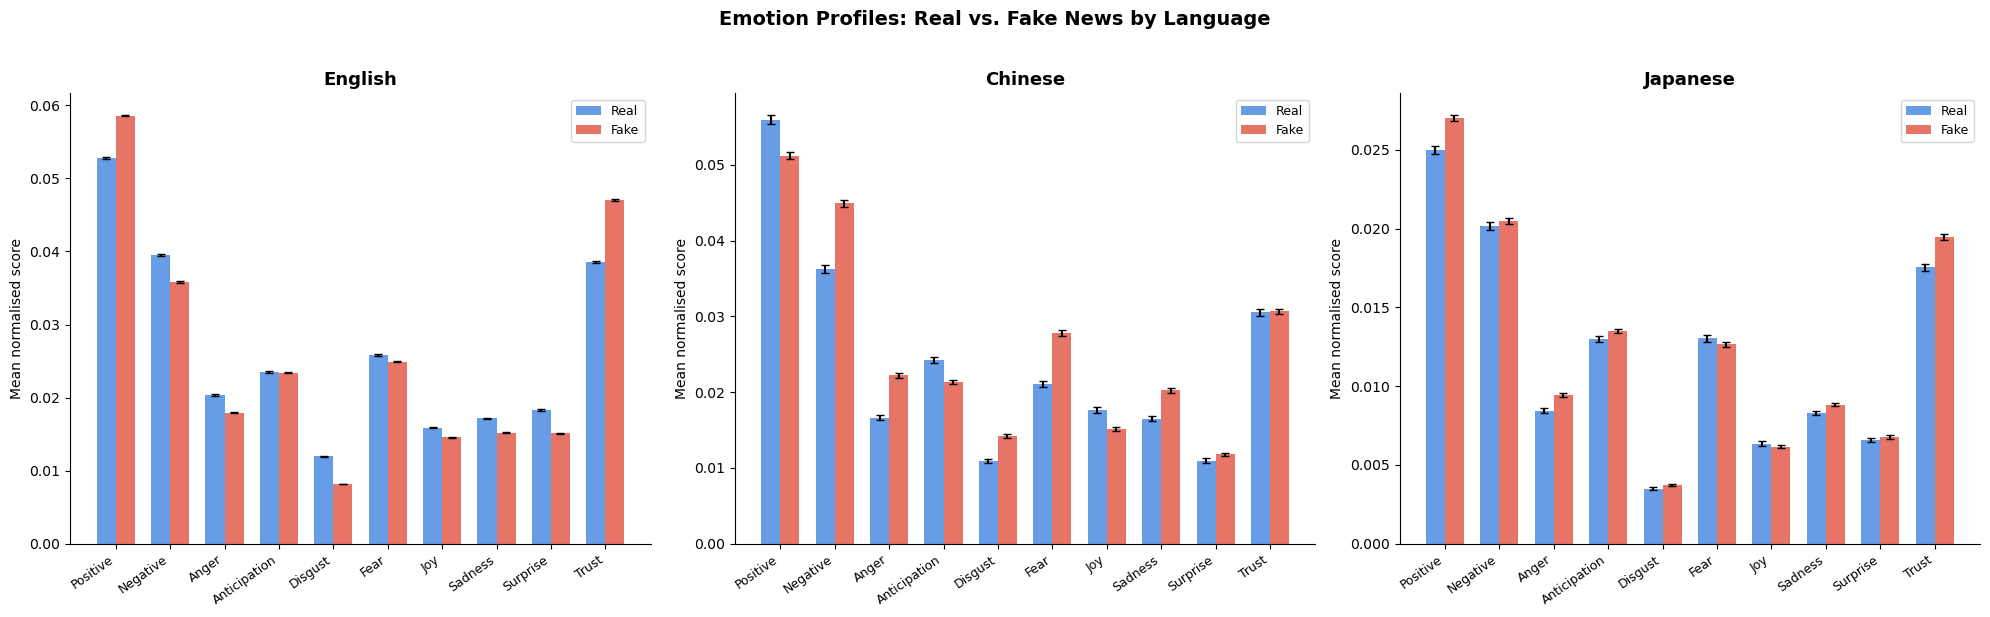

<Figure size 640x480 with 0 Axes>

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

colors = {'real': '#4C8BE2', 'fake': '#E25C4C'}
x = np.arange(len(EMOTIONS))
width = 0.35

for ax, (lang, tbl) in zip(axes, agg_tables.items()):
    # bars
    bars_real = ax.bar(x - width/2, tbl['real_mean'], width,
                   yerr=tbl['real_sem'], capsize=3,
                   color=colors['real'], alpha=0.85, label='Real')
    bars_fake = ax.bar(x + width/2, tbl['fake_mean'], width,
                   yerr=tbl['fake_sem'], capsize=3,
                   color=colors['fake'], alpha=0.85, label='Fake')

    ax.set_title(lang, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(EMOTIONS, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Mean normalised score')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Emotion Profiles: Real vs. Fake News by Language',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

plt.savefig("tables and figures/Emotion profiles real vs. fake.png")

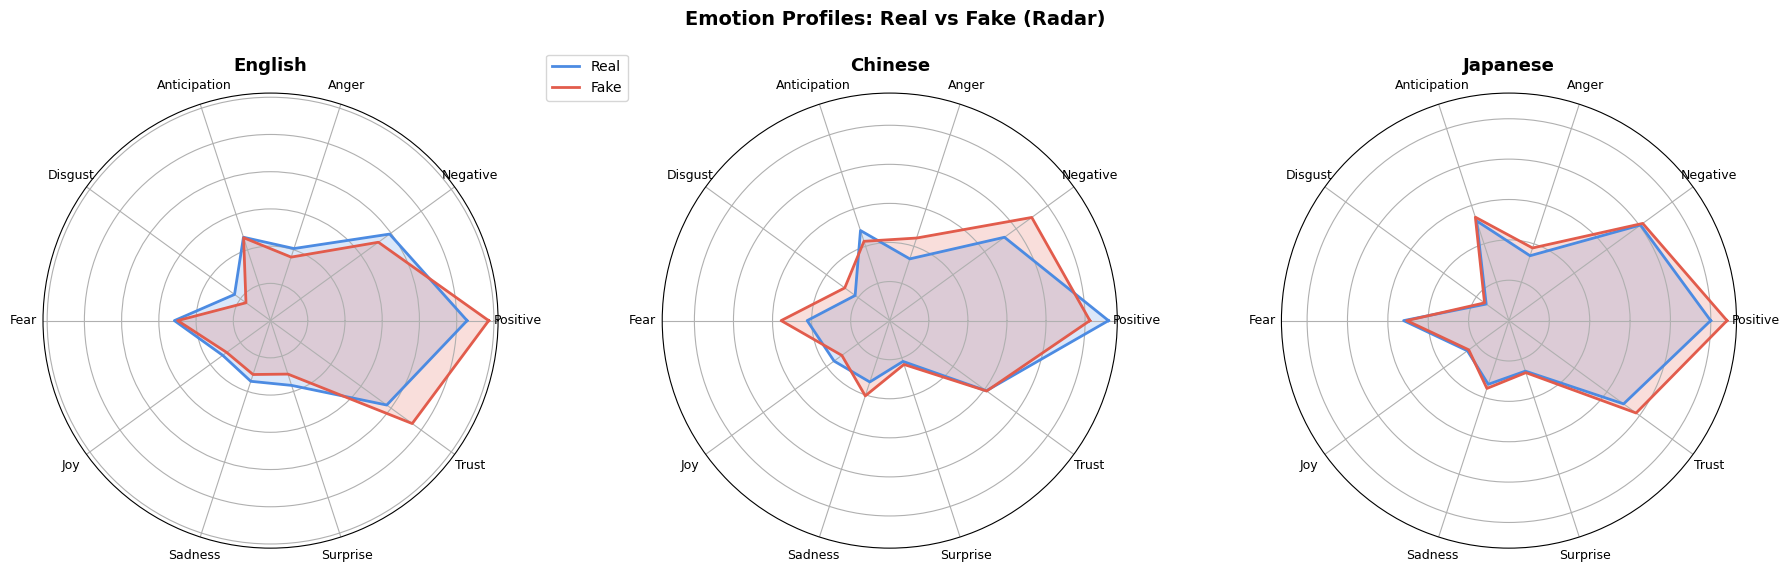

In [51]:
import numpy as np
import matplotlib.pyplot as plt

EMOTIONS = list(next(iter(agg_tables.values())).index)

N = len(EMOTIONS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the circle

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))

colors = {'real': '#4C8BE2', 'fake': '#E25C4C'}

for ax, (lang, tbl) in zip(axes, agg_tables.items()):
    real = tbl['real_mean'].tolist()
    fake = tbl['fake_mean'].tolist()
    
    # close the loop
    real += real[:1]
    fake += fake[:1]
    
    # plot
    ax.plot(angles, real, color=colors['real'], linewidth=2, label='Real')
    ax.fill(angles, real, color=colors['real'], alpha=0.2)
    
    ax.plot(angles, fake, color=colors['fake'], linewidth=2, label='Fake')
    ax.fill(angles, fake, color=colors['fake'], alpha=0.2)
    
    # labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(EMOTIONS, fontsize=9)
    
    ax.set_title(lang, fontsize=13, fontweight='bold')
    ax.set_yticklabels([])  # cleaner look

# legend (shared)
axes[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

fig.suptitle('Emotion Profiles: Real vs Fake (Radar)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tables and figures/emotion_radar.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical Analyses

In [52]:
from scipy.stats import skew, kurtosis

for lang, df in scored.items():
    print(f"\n── {lang} ──")
    rows = []
    for emotion in EMOTIONS:
        for label, name in [(0, 'real'), (1, 'fake')]:
            vals = df[df['label'] == label][emotion]
            rows.append({
                'emotion': emotion,
                'group': name,
                'skewness': round(skew(vals), 3),
                'kurtosis': round(kurtosis(vals), 3),  # excess kurtosis, 0=normal
                'zero_pct': round((vals == 0).mean() * 100, 1)
            })
    print(pd.DataFrame(rows).to_string(index=False))


── English ──
     emotion group  skewness  kurtosis  zero_pct
    Positive  real     7.195   209.485       3.6
    Positive  fake     1.121     3.826       0.3
    Negative  real     6.394   161.290       4.5
    Negative  fake     0.856     1.883       2.4
       Anger  real     3.329    29.533       9.5
       Anger  fake     1.696     7.310       8.3
Anticipation  real    10.316   358.800       6.8
Anticipation  fake     1.576     7.854       3.4
     Disgust  real    16.964   821.673      15.3
     Disgust  fake     2.173     9.972      17.9
        Fear  real     3.289    36.549       7.1
        Fear  fake     1.475     4.604       5.5
         Joy  real    13.165   547.682      10.8
         Joy  fake     1.712     6.183       7.9
     Sadness  real     5.235    95.101      10.5
     Sadness  fake     1.820     7.201       9.4
    Surprise  real     3.977    48.552      10.9
    Surprise  fake     1.501     4.239       8.3
       Trust  real     8.879   299.672       5.0
     

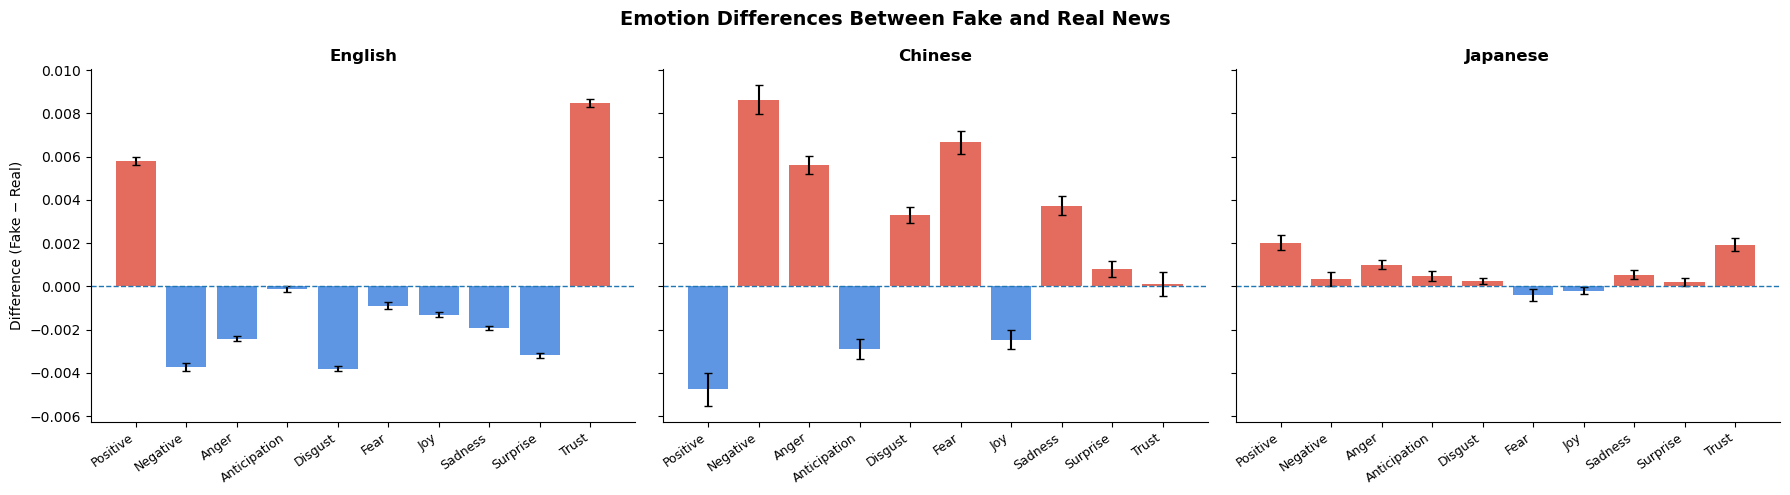

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (lang, tbl) in zip(axes, agg_tables.items()):
    diff = tbl['diff (fake-real)']
    
    # propagate SEM: sqrt(sem_real^2 + sem_fake^2)
    err = np.sqrt(tbl['real_sem']**2 + tbl['fake_sem']**2)
    
    colors = ['#E25C4C' if d > 0 else '#4C8BE2' for d in diff]

    ax.bar(EMOTIONS, diff, yerr=err, capsize=3, color=colors, alpha=0.9)
    ax.axhline(0, linestyle='--', linewidth=1)

    ax.set_title(lang, fontweight='bold')
    ax.set_xticks(range(len(EMOTIONS)))
    ax.set_xticklabels(EMOTIONS, rotation=35, ha='right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Difference (Fake − Real)')

fig.suptitle('Emotion Differences Between Fake and Real News',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('emotion_diff_plot_clean.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\acl13\AppData\Local\Temp\ipykernel_15572\4150972924.py:14: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\acl13\AppData\Local\Temp\ipykernel_15572\4150972924.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(EMOTIONS, rotation=35, ha='right')
C:\Users\acl13\AppData\Local\Temp\ipykernel_15572\4150972924.py:14: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\acl13\AppData\Local\Temp\ipykernel_15572\4150972924.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(EMOTIONS, rotation=35, ha='right')
C:\Users\acl13\AppData\Local\Temp\ipykernel_15572\

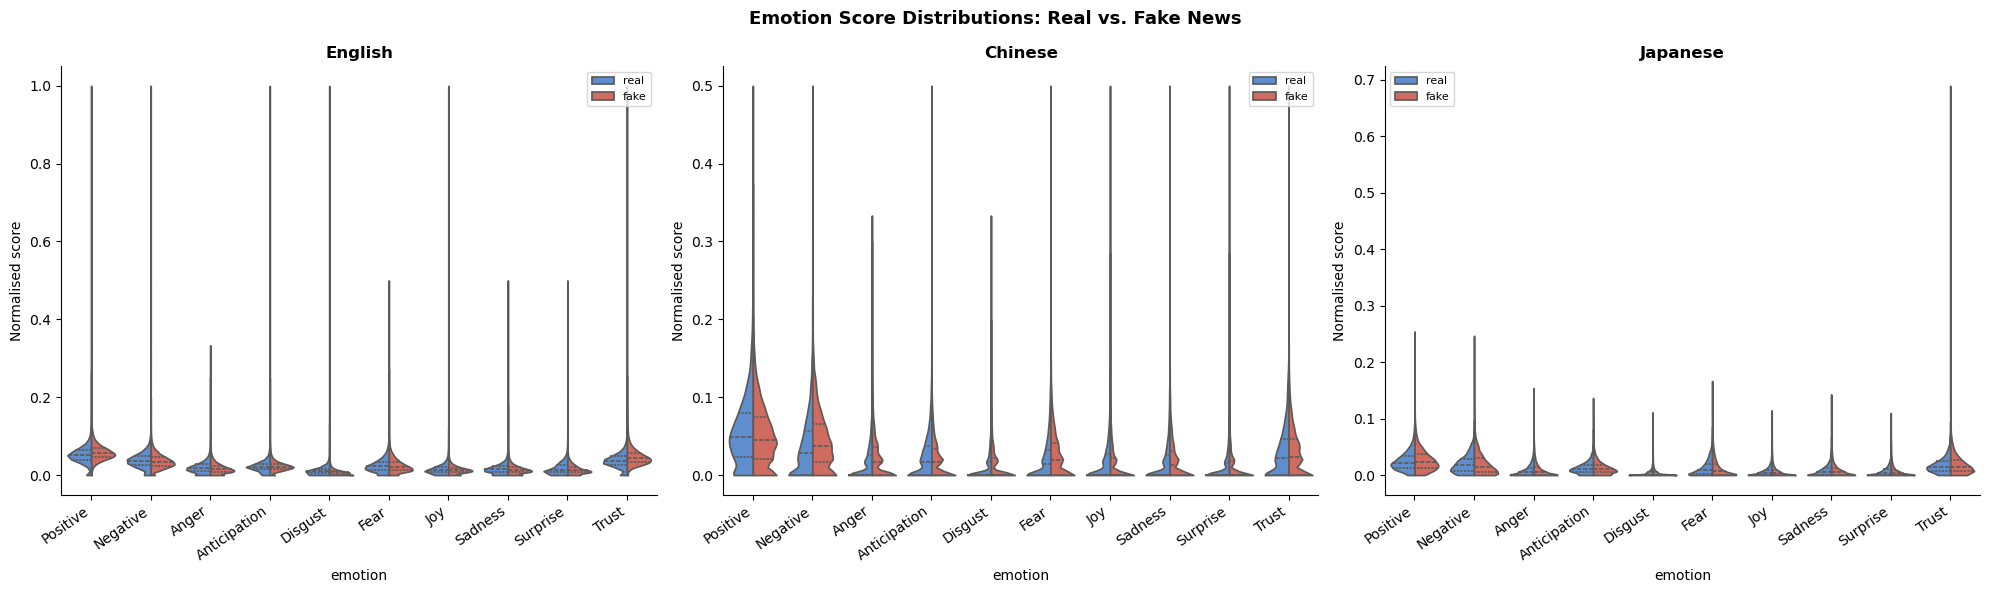

In [53]:
# violin plot that summarizes distributions

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (lang, df) in zip(axes, scored.items()):
    # melt to long format for seaborn
    long = df[['label'] + EMOTIONS].melt(
        id_vars='label',
        var_name='emotion',
        value_name='score'
    )
    long['group'] = long['label'].map({0: 'real', 1: 'fake'})

    sns.violinplot(
        data=long, x='emotion', y='score', hue='group',
        ax=ax, split=True, inner='quart',
        palette={'real': '#4C8BE2', 'fake': '#E25C4C'},
        scale='width', cut=0  # cut=0 stops violins extending below 0
    )
    ax.set_title(lang, fontweight='bold')
    ax.set_xticklabels(EMOTIONS, rotation=35, ha='right')
    ax.set_ylabel('Normalised score')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Emotion Score Distributions: Real vs. Fake News',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('emotion_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
# lack of normality rules out T-test
# conduct Mann-Whitney U test instead

#False discovery rate correction was applied within each language across emotion categories

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

results = []

# helper: effect size interpretation
def interpret_r(r):
    if abs(r) < 0.1:
        return 'negligible'
    elif abs(r) < 0.3:
        return 'small'
    elif abs(r) < 0.5:
        return 'medium'
    else:
        return 'large'

# --- main loop ---
for lang, df in scored.items():
    real = df[df['label'] == 0]
    fake = df[df['label'] == 1]
    
    n1 = len(fake)
    n2 = len(real)

    for emotion in EMOTIONS:
        x = fake[emotion]
        y = real[emotion]

        stat, p = mannwhitneyu(x, y, alternative='two-sided')

        # rank-biserial correlation (correct)
        r = (2 * stat) / (n1 * n2) - 1

        results.append({
            'language': lang,
            'emotion': emotion,

            # central tendency
            'mean_real': y.mean(),
            'mean_fake': x.mean(),
            'median_real': y.median(),
            'median_fake': x.median(),

            # difference (matches your plots)
            'diff_mean (fake-real)': x.mean() - y.mean(),

            # test stats
            'U_stat': stat,
            'p_value': p,

            # effect size
            'effect_r': r,
            'effect_size': interpret_r(r),

            # sample sizes (good practice)
            'n_real': n2,
            'n_fake': n1
        })

# --- combine into one table ---
results_df = pd.DataFrame(results)

# --- global FDR correction across ALL tests ---
rejected, p_fdr, _, _ = multipletests(results_df['p_value'], method='fdr_bh')

results_df['p_fdr'] = p_fdr
results_df['significant'] = rejected

# --- optional: round for readability ---
results_df = results_df.round({
    'mean_real': 5,
    'mean_fake': 5,
    'median_real': 5,
    'median_fake': 5,
    'diff_mean (fake-real)': 5,
    'p_value': 6,
    'p_fdr': 6,
    'effect_r': 4
})

# --- sort for clarity (optional but nice) ---
results_df = results_df.sort_values(
    ['language', 'diff_mean (fake-real)'],
    ascending=[True, False]
)

def stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

results_df['sig_star'] = results_df['p_fdr'].apply(stars)

# --- save outputs ---
results_df.to_csv('emotion_stats_full.csv', index=False)
results_df.to_latex('emotion_stats_full.tex', index=False)

# preview
print(results_df.head())

   language   emotion  mean_real  mean_fake  median_real  median_fake  \
11  Chinese  Negative    0.03630    0.04493      0.02806      0.03774   
15  Chinese      Fear    0.02114    0.02780      0.01370      0.01923   
12  Chinese     Anger    0.01661    0.02222      0.00000      0.01667   
17  Chinese   Sadness    0.01652    0.02026      0.00000      0.01336   
14  Chinese   Disgust    0.01095    0.01424      0.00000      0.00000   

    diff_mean (fake-real)      U_stat  p_value  effect_r effect_size  n_real  \
11                0.00863  29786394.0      0.0    0.1323       small    5444   
15                0.00666  29535576.5      0.0    0.1228       small    5444   
12                0.00561  29531748.0      0.0    0.1226       small    5444   
17                0.00374  28324402.5      0.0    0.0768  negligible    5444   
14                0.00329  28613342.0      0.0    0.0877  negligible    5444   

    n_fake  p_fdr  significant sig_star  
11    9664    0.0         True      **

In [123]:
en_clean.to_csv('data/en_clean.csv', index = False)
cn_clean.to_csv('data/cn_clean.csv', index = False)
jp_clean.to_csv('data/jp_clean.csv', index = False)

# REDO THESE!!! THE RESULTS HAVE BEEN UPDATED AFTER MORE RIGOROUS CLEANING!

EN: all significant. 
Effect sizes large to small: (neglected the ones smaller than .1)
* disgust (.21)
* trust (-.18)
* positive (-.11)
* negative (.11)
* anger (.1)

CN: all significant.
Effect sizes large to small: 
* anticipation (.13)
* joy (.12)
* negative (-.12)
* positive (.10)

JP: all significant except anger & trust
Effect sizes large to small:
* fear (.08) 
the rest are too small. 


In [63]:
cn['label'].value_counts()

label
1    9664
0    5444
Name: count, dtype: int64

In [64]:
en['label'].value_counts(
)

label
1    34791
0    28881
Name: count, dtype: int64

In [65]:
jp[['label']].value_counts()

label
1        9624
0        3686
Name: count, dtype: int64